In [124]:
import pandas as pd
from orderbook import OrderBook
import numpy as np
from scipy.stats import norm
from orderbook import unittest1
import matplotlib.pyplot as plt
import seaborn as sns

In [130]:
data30 = pd.read_excel("./data/input_data_30_pv.xlsx")
data30["clock"]=pd.to_datetime(data30["clock"],format="%H:%M:%S").dt.strftime('%H:%M')
data30.set_index(["Time","ID"],inplace=True)

data50 = pd.read_excel("./data/input_data_50_pv.xlsx")
data50["clock"]=pd.to_datetime(data50["clock"],format="%H:%M:%S").dt.strftime('%H:%M')
data50.set_index(["Time","ID"],inplace=True)

data70 = pd.read_excel("./data/input_data_70_pv.xlsx")
data70["clock"]=pd.to_datetime(data70["clock"],format="%H:%M:%S").dt.strftime('%H:%M')
data70.set_index(["Time","ID"],inplace=True)

In [129]:
#add energy_sold 
#sim_data["energy_in"] =np.zeros(len(sim_data))
#sim_data["energy_out"] =np.zeros(len(sim_data))
#sim_data["money_in"] =np.zeros(len(sim_data))
#sim_data["money_out"] =np.zeros(len(sim_data))
#sim_data["surplus"]=sim_data["pv_gen"]-sim_data["load"]


example_data= pd.DataFrame(columns=["Time","Seller ID","Buyer ID","Price","Quantity"])
def execute_order(trader_buy,trader_sell,price,size,cycle,data):
    print("EXECUTE: %s BUY %s SELL %s @ %d" % (trader_buy, trader_sell, size, price))
    data.loc[(cycle,trader_buy),"energy_out"] += size/1000
    data.loc[(cycle,trader_buy),"money_in"] += price/1000*size/1000
    data.loc[(cycle,trader_sell),"energy_in"] += size/1000
    data.loc[(cycle,trader_sell),"money_out"] += price/1000*size/1000
    if trader_buy == 1 or trader_sell == 1:
        example_data.loc[len(example_data)]= [data.loc[(cycle,1),"clock"],trader_sell,trader_buy,price/1000,size/1000]
def simulate(data):
    sim_data = data.copy()
    sim_data["energy_in"] =np.zeros(len(sim_data))
    sim_data["energy_out"] =np.zeros(len(sim_data))
    sim_data["money_in"] =np.zeros(len(sim_data))
    sim_data["money_out"] =np.zeros(len(sim_data))
    for i in data.index.get_level_values(0).unique():
        slice  = sim_data.xs(i)
        sellers = slice[slice.surplus>0].sort_values("bid_price_sellers",ascending=True)
        buyers = slice[slice.demand>0].sort_values("bid_price_buyers",ascending=False)
        ob = OrderBook(str(i),cb=execute_order)
        for id,row in buyers.iterrows():
            ob.limit_order(0,round(row.demand*1000),round(row.bid_price_buyers*1000),id,i,sim_data)
        for id,row in sellers.iterrows():
            ob.limit_order(1,round(row.surplus*1000),round(row.bid_price_sellers*1000),id,i,sim_data)
        
    return sim_data

In [127]:
simulate(data50)
example_data.to_excel("example_data_OBM.xlsx")

KeyError: 1

In [116]:
c =data70["clock"]

In [131]:
order_book_results30 = simulate(data30)
order_book_results30.loc[order_book_results30["surplus"]>0,"price"]=order_book_results30[order_book_results30["surplus"]>0].apply(lambda x: x["money_out"]/x["energy_in"] if x.energy_in > 0 else None,axis=1)
order_book_results30.loc[order_book_results30["demand"]>0,"price"]=order_book_results30[order_book_results30["demand"]>0].apply(lambda x: x["money_in"]/x["energy_out"] if x.energy_out > 0 else None,axis=1)
order_book_results50 = simulate(data50)
order_book_results50.loc[order_book_results50["surplus"]>0,"price"]=order_book_results50[order_book_results50["surplus"]>0].apply(lambda x: x["money_out"]/x["energy_in"] if x.energy_in > 0 else None,axis=1)
order_book_results50.loc[order_book_results50["demand"]>0,"price"]=order_book_results50[order_book_results50["demand"]>0].apply(lambda x: x["money_in"]/x["energy_out"] if x.energy_out > 0 else None,axis=1)
order_book_results70 = simulate(data70)
order_book_results70.loc[order_book_results70["surplus"]>0,"price"]=order_book_results70[order_book_results70["surplus"]>0].apply(lambda x: x["money_out"]/x["energy_in"] if x.energy_in > 0 else None,axis=1)
order_book_results70.loc[order_book_results70["demand"]>0,"price"]=order_book_results70[order_book_results70["demand"]>0].apply(lambda x: x["money_in"]/x["energy_out"] if x.energy_out > 0 else None,axis=1)

order_book_results30.to_excel("./simulation_results/OBM_result_data_30_pv.xlsx")
order_book_results50.to_excel("./simulation_results/OBM_result_data_50_pv.xlsx")
order_book_results70.to_excel("./simulation_results/OBM_result_data_70_pv.xlsx")

EXECUTE: 32 BUY 37 SELL 16 @ 90
EXECUTE: 241 BUY 37 SELL 465 @ 154
EXECUTE: 176 BUY 37 SELL 227 @ 154
EXECUTE: 176 BUY 50 SELL 21 @ 157
EXECUTE: 176 BUY 41 SELL 23 @ 159
EXECUTE: 196 BUY 151 SELL 70 @ 128
EXECUTE: 196 BUY 4 SELL 12 @ 129
EXECUTE: 196 BUY 37 SELL 557 @ 131
EXECUTE: 157 BUY 37 SELL 49 @ 131
EXECUTE: 157 BUY 40 SELL 67 @ 140
EXECUTE: 157 BUY 147 SELL 154 @ 141
EXECUTE: 157 BUY 54 SELL 588 @ 157
EXECUTE: 117 BUY 37 SELL 868 @ 87
EXECUTE: 61 BUY 37 SELL 93 @ 87
EXECUTE: 61 BUY 45 SELL 68 @ 110
EXECUTE: 61 BUY 4 SELL 100 @ 151
EXECUTE: 61 BUY 41 SELL 44 @ 161
EXECUTE: 223 BUY 37 SELL 1847 @ 45
EXECUTE: 223 BUY 4 SELL 3 @ 86
EXECUTE: 52 BUY 4 SELL 215 @ 86
EXECUTE: 62 BUY 4 SELL 202 @ 86
EXECUTE: 62 BUY 40 SELL 172 @ 91
EXECUTE: 22 BUY 40 SELL 42 @ 91
EXECUTE: 165 BUY 40 SELL 270 @ 91
EXECUTE: 165 BUY 247 SELL 60 @ 92
EXECUTE: 108 BUY 247 SELL 34 @ 92
EXECUTE: 108 BUY 45 SELL 76 @ 97
EXECUTE: 108 BUY 147 SELL 8 @ 117
EXECUTE: 202 BUY 147 SELL 98 @ 117
EXECUTE: 36 BUY 147 SELL

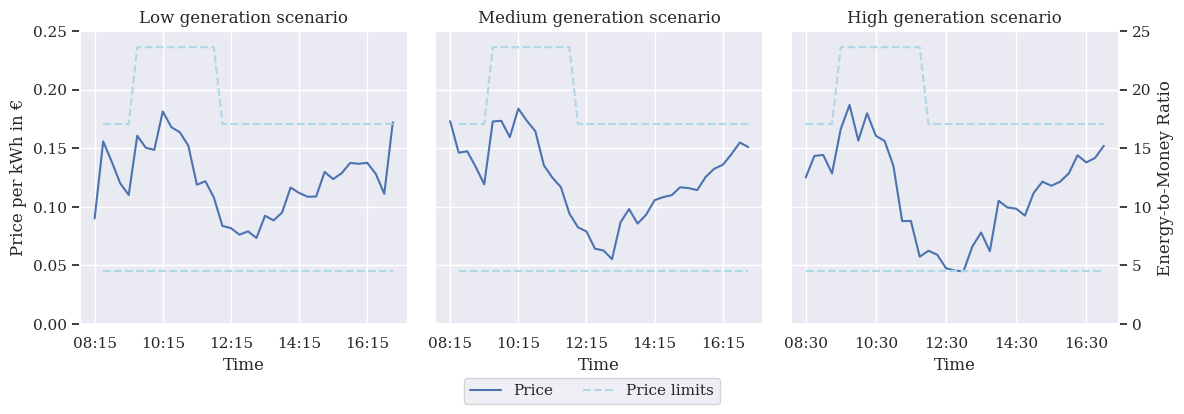

In [132]:
agg30 = order_book_results30.groupby("clock").agg({"energy_in":"sum","energy_out":"sum","money_in":"sum","money_out":"sum","price":"mean","buy_price":"mean","sell_price":"min"}).reset_index()
agg50 = order_book_results50.groupby("clock").agg({"energy_in":"sum","energy_out":"sum","money_in":"sum","money_out":"sum","price":"mean","buy_price":"mean","sell_price":"min"}).reset_index()
agg70 = order_book_results70.groupby("clock").agg({"energy_in":"sum","energy_out":"sum","money_in":"sum","money_out":"sum","price":"mean","buy_price":"mean","sell_price":"min"}).reset_index()
plt.rc('axes', axisbelow=True)
sns.set_theme(style="darkgrid")
sns.set_style({'font.family':'serif', 'font.serif':'Times New Roman'})
prices_low = agg30[agg30["energy_in"]>0]["price"]
times_low = agg30[agg30["energy_in"]>0]["clock"]
prices_mid = agg50[agg50["energy_in"]>0]["price"]
times_mid = agg50[agg50["energy_in"]>0]["clock"]
prices_high = agg70[agg70["energy_in"]>0]["price"]
times_high = agg70[agg70["energy_in"]>0]["clock"]
upper = agg70[agg70["energy_in"]>0]["buy_price"]
lower = agg70[agg70["energy_in"]>0]["sell_price"]
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
ax1= axes[0].twinx()
ax2= axes[1].twinx()
ax3= axes[2].twinx()

# Determine the highest y-axis limit for prices
max_y = prices_high.max()

# Low generation scenario
sns.lineplot(ax=axes[0], x=times_low, y=prices_low, label="Price",legend=False)
sns.lineplot(ax=axes[0], x=times_high, y=upper, label="Price limits",legend=False,linestyle='dashed',color='lightblue')
sns.lineplot(ax=axes[0], x=times_high, y=lower, label=None,legend=False,linestyle='dashed',color='lightblue')
axes[0].set_title("Low generation scenario")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Price per kWh in €")
axes[0].set_ylim(0, 0.25)
axes[0].set_xticks(np.arange(0, len(prices_high), 8))
ax1.tick_params('y',right=False, labelright=False)
ax1.set_ylabel(None)
ax1.grid(False)

# Medium generation scenario
sns.lineplot(ax=axes[1], x=times_mid, y=prices_mid)
sns.lineplot(ax=axes[1], x=times_high, y=upper, label=None,legend=False,linestyle='dashed',color='lightblue')
sns.lineplot(ax=axes[1], x=times_high, y=lower, label=None,legend=False,linestyle='dashed',color='lightblue')
axes[1].set_title("Medium generation scenario")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Price per kWh in €")
axes[1].set_xticks(np.arange(0, len(prices_high), 8))
axes[1].tick_params('y',left=False, labelleft=False)
ax2.tick_params('y',right=False, labelright=False)
ax2.set_ylabel(None)
ax2.grid(False)

# High generation scenario
sns.lineplot(ax=axes[2], x=times_high, y=prices_high)
sns.lineplot(ax=axes[2], x=times_high, y=upper, label=None,legend=False,linestyle='dashed',color='lightblue')
sns.lineplot(ax=axes[2], x=times_high, y=lower, label=None,legend=False,linestyle='dashed',color='lightblue')
axes[2].set_title("High generation scenario")
axes[2].set_xlabel("Time")
axes[2].set_ylabel("Price per kWh in €")
axes[2].tick_params('y',left=False, labelleft=False)
axes[2].set_xticks(np.arange(0, len(prices_high), 8))
ax3.set_ylabel("Energy-to-Money Ratio")
ax3.set_ylim(0, 25)
ax1.sharey(ax3)
ax2.sharey(ax3)
ax3.grid(False)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(loc=8,ncols=3,bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()
fig.get_figure()
fig.savefig("./Images/Prices_scenarios.png",bbox_inches='tight')


,load,pv_gen,ev_load,buy_price,sell_price,surplus,demand,cost of demand,bid_price_sellers,bid_price_buyers,energy_in,energy_out,money_in,money_out,price
count,250.000000,250.000000,250.0,250.000000,250.000,250.000000,250.000000,250.000000,66.000000,184.000000,250.000000,250.000000,250.000000,250.000000,197.000000
mean,1.059805,0.808473,0.0,0.170652,0.045,0.537542,0.788874,0.134503,0.071864,0.142365,0.537542,0.537542,0.038700,0.038700,0.071963
std,0.909533,1.801726,0.0,0.001708,0.000,1.284978,0.893503,0.152041,0.003184,0.010961,1.284978,0.802950,0.057817,0.093069,0.003140
min,0.041467,0.000000,0.0,0.162300,0.045,0.000000,0.000000,0.000000,0.063327,0.110841,0.000000,0.000000,0.000000,0.000000,0.063300
25%,0.371097,0.000000,0.0,0.171000,0.045,0.000000,0.000000,0.000000,0.069796,0.136613,0.000000,0.000000,0.000000,0.000000,0.070300
50%,0.747630,0.000000,0.0,0.171000,0.045,0.000000,0.505330,0.086411,0.072396,0.143048,0.000000,0.118517,0.008853,0.000000,0.072500
75%,1.578537,0.731159,0.0,0.171000,0.045,0.307976,1.203007,0.205714,0.074035,0.150251,0.307976,0.710964,0.051451,0.022848,0.074300
max,4.275379,8.857321,0.0,0.171000,0.045,7.670439,3.617077,0.618520,0.078226,0.164728,7.670439,3.617077,0.268755,0.569914,0.078200


In [20]:
buyers.xs(53)

Time     53.000000
price     0.133964
Name: 52, dtype: float64

In [11]:
buyers[54]

KeyError: 54

In [55]:
sim_data.xs((95,1))

load          0.245914
pv_gen             0.0
buy_price        0.171
sell_price       0.045
clock         23:30:00
Name: (95, 1), dtype: object